In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [3]:
df=pd.read_csv("Housing_dataset_train.csv")

DATA EXPLORATION

In [4]:
df.head()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [5]:
df.shape

(14000, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             14000 non-null  int64  
 1   loc            12187 non-null  object 
 2   title          12278 non-null  object 
 3   bedroom        12201 non-null  float64
 4   bathroom       12195 non-null  float64
 5   parking_space  12189 non-null  float64
 6   price          14000 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 765.8+ KB


In [7]:
df.describe()

,ID,bedroom,bathroom,parking_space,price
count,14000.000000,12201.000000,12195.000000,12189.000000,1.400000e+04
mean,4862.700357,4.308171,3.134235,3.169825,2.138082e+06
std,3818.348214,2.441165,2.035950,1.599415,1.083057e+06
min,0.000000,1.000000,1.000000,1.000000,4.319673e+05
25%,1672.750000,2.000000,1.000000,2.000000,1.393990e+06
50%,3527.000000,4.000000,2.000000,3.000000,1.895223e+06
75%,8011.250000,6.000000,5.000000,4.000000,2.586699e+06
max,12999.000000,9.000000,7.000000,6.000000,1.656849e+07


In [8]:
df.isnull()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False
2,False,False,True,False,False,True,False
3,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
13995,False,False,False,True,False,True,False
13996,False,False,False,True,False,False,False
13997,False,False,False,False,False,False,False
13998,False,False,False,True,False,False,False


In [9]:
df.isnull().sum()

ID                  0
loc              1813
title            1722
bedroom          1799
bathroom         1805
parking_space    1811
price               0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

ID                0.000000
loc              12.950000
title            12.300000
bedroom          12.850000
bathroom         12.892857
parking_space    12.935714
price             0.000000
dtype: float64

In [15]:
df.columns

Index(['ID', 'loc', 'title', 'bedroom', 'bathroom', 'parking_space', 'price'], dtype='object')

In [12]:
df['bedroom'].value_counts()

bedroom
5.0    1789
2.0    1741
1.0    1738
3.0    1736
4.0    1641
6.0     908
7.0     888
9.0     883
8.0     877
Name: count, dtype: int64

In [13]:
df["bathroom"].value_counts()

bathroom
1.0    3272
2.0    3255
7.0    1156
5.0    1143
6.0    1138
3.0    1119
4.0    1112
Name: count, dtype: int64

In [14]:
df["parking_space"].value_counts()

parking_space
4.0    2419
2.0    2394
3.0    2378
1.0    2324
6.0    1345
5.0    1329
Name: count, dtype: int64

CHANGING THE LOCATION AND TITLE COLUMN  

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()


df["loc"] =le.fit_transform(df["loc"])
df["title"] = le.fit_transform(df["title"])`

In [117]:
df=df.rename(columns={"loc":"location"})

In [118]:
df.head()

,location,title,bedroom,bathroom,parking_space,price
0,19,7,2.000000,2.0,1.00,1149999.565
1,27,0,4.308171,2.0,4.00,1672416.689
2,12,10,7.000000,5.0,3.17,3364799.814
3,3,3,5.000000,2.0,4.00,2410306.756
4,21,8,4.308171,5.0,6.00,2600700.898


In [20]:
df.drop("ID", axis=1, inplace=True)

In [21]:
df.head()

,loc,title,bedroom,bathroom,parking_space,price
0,19,7,2.0,2.0,1.0,1149999.565
1,27,0,NaN,2.0,4.0,1672416.689
2,12,10,7.0,5.0,NaN,3364799.814
3,3,3,5.0,2.0,4.0,2410306.756
4,21,8,NaN,5.0,6.0,2600700.898


DATA VISUALIZATION AND FILLING OF MISSING VALUE OF EACH COLUMN WITH THE MEAN OF EACH COLUMN

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

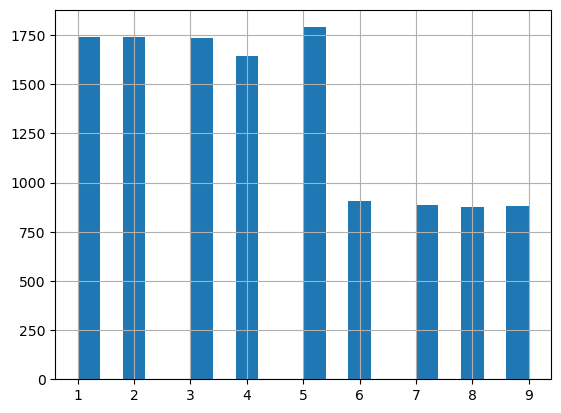

In [24]:
df.bedroom.hist(bins=20)

<Axes: >

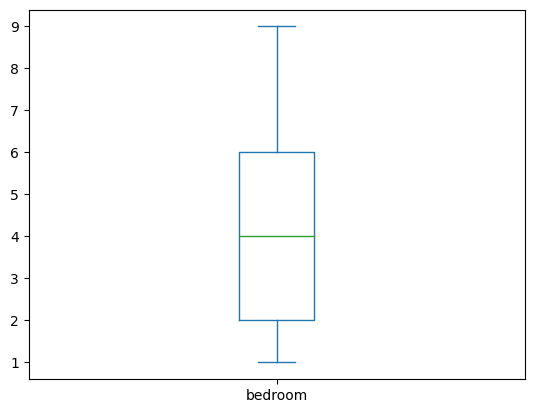

In [28]:
df.bedroom.plot(kind='box')

In [57]:
df.bedroom.fillna(df.bedroom.mean().round(2), inplace=True)

In [58]:
df.bedroom

0        2.000000
1        4.308171
2        7.000000
3        5.000000
4        4.308171
           ...   
13995    4.308171
13996    4.308171
13997    8.000000
13998    4.308171
13999    9.000000
Name: bedroom, Length: 14000, dtype: float64

In [43]:
df.bedroom.isnull().sum()

0

In [59]:
df.bedroom.unique()

array([2.        , 4.30817146, 7.        , 5.        , 3.        ,
       1.        , 4.        , 6.        , 9.        , 8.        ])

<Axes: >

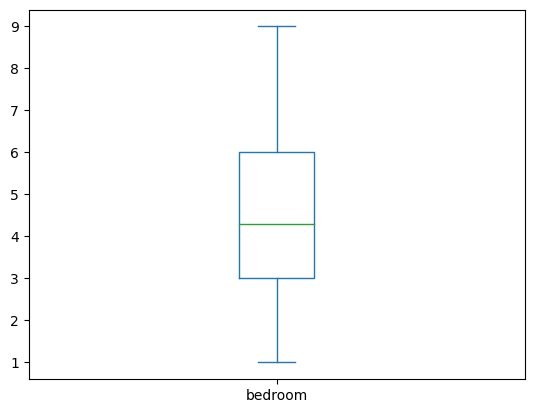

In [60]:
df.bedroom.plot(kind="box")

<Axes: >

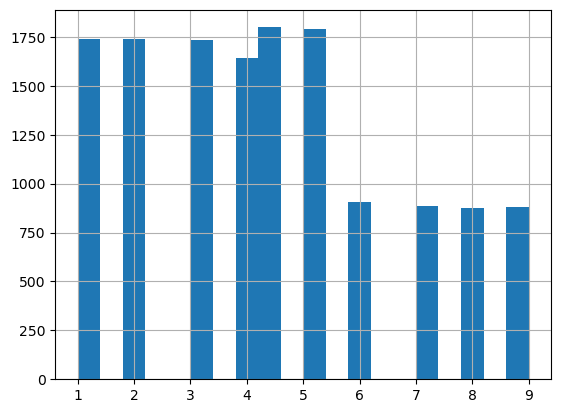

In [61]:
df.bedroom.hist(bins=20)

In [63]:
df.bathroom

0        2.0
1        2.0
2        5.0
3        2.0
4        5.0
        ... 
13995    7.0
13996    7.0
13997    6.0
13998    6.0
13999    7.0
Name: bathroom, Length: 14000, dtype: float64

In [65]:
df.bathroom.isnull().sum()

1805

In [67]:
df.bathroom.unique()

array([ 2.,  5.,  1.,  4.,  3., nan,  7.,  6.])

<Axes: >

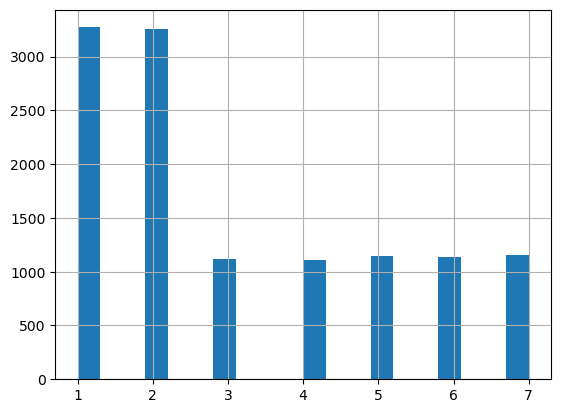

In [68]:
df.bathroom.hist(bins=20)

<Axes: >

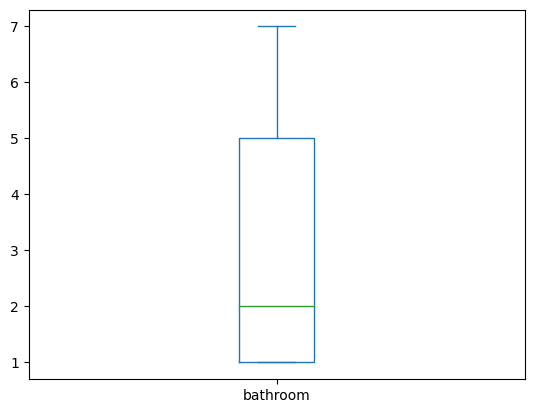

In [69]:
df.bathroom.plot(kind="box")

In [71]:
df.bathroom.fillna(df.bathroom.mean().round(2),inplace=True)

In [73]:
df.bathroom

0        2.0
1        2.0
2        5.0
3        2.0
4        5.0
        ... 
13995    7.0
13996    7.0
13997    6.0
13998    6.0
13999    7.0
Name: bathroom, Length: 14000, dtype: float64

In [75]:
df.bathroom.isnull().sum()

0

In [77]:
df.bathroom.unique()

array([2.  , 5.  , 1.  , 4.  , 3.  , 3.13, 7.  , 6.  ])

<Axes: >

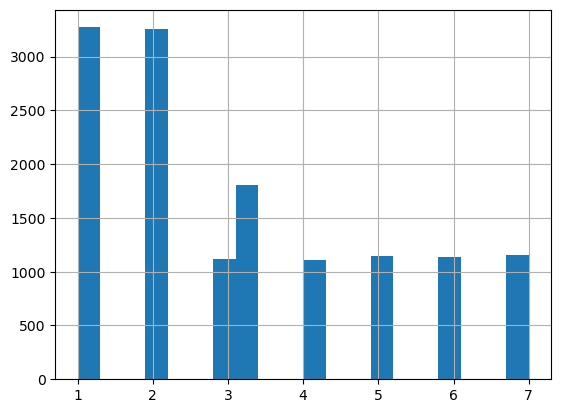

In [79]:
df.bathroom.hist(bins=20)

<Axes: >

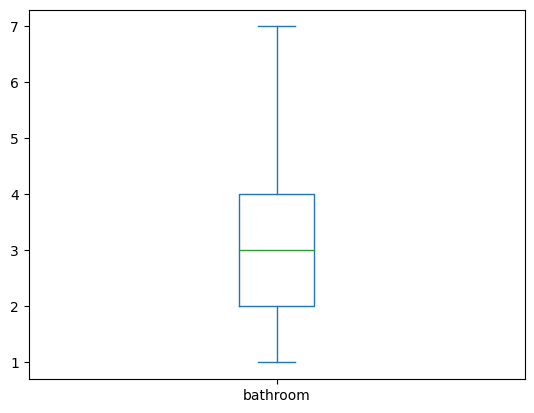

In [80]:
df.bathroom.plot(kind="box")

<Axes: xlabel='bedroom', ylabel='bathroom'>

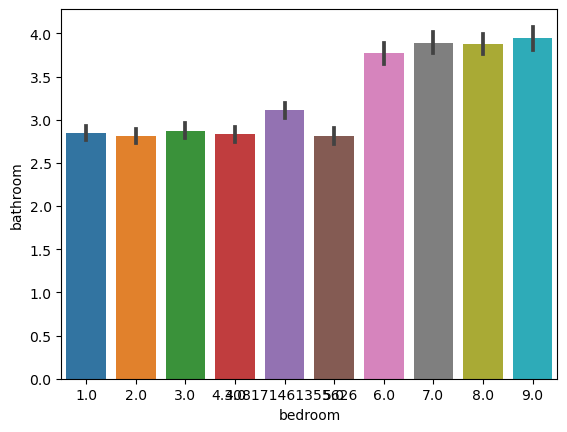

In [81]:
sns.barplot(df, x="bedroom", y="bathroom")

In [90]:
df.parking_space

0        1.00
1        4.00
2        3.17
3        4.00
4        6.00
         ... 
13995    3.17
13996    5.00
13997    5.00
13998    1.00
13999    5.00
Name: parking_space, Length: 14000, dtype: float64

In [85]:
df.parking_space.isnull().sum()

1811

<Axes: >

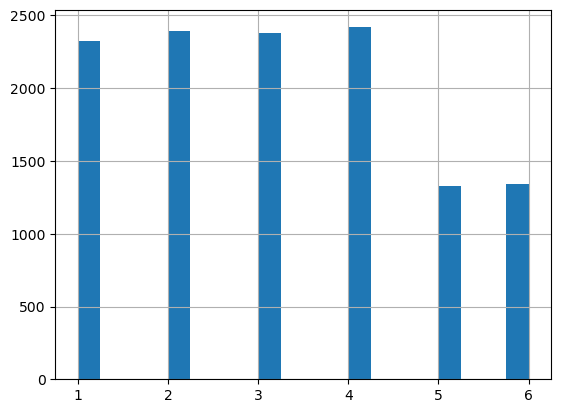

In [86]:
df.parking_space.hist(bins=20)

<Axes: >

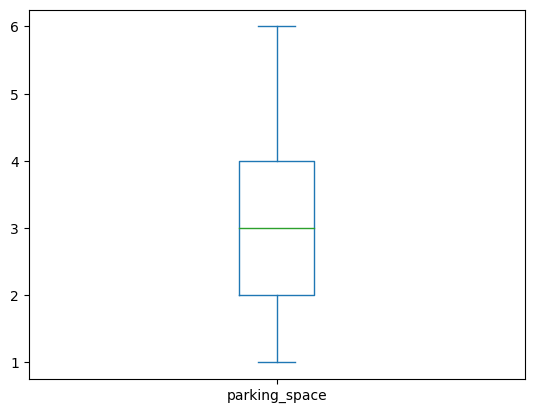

In [87]:
df.parking_space.plot(kind="box")

In [88]:
df.parking_space.fillna(df.parking_space.mean().round(2), inplace=True)

In [195]:
df.parking_space.head()

0    1.00
1    4.00
2    3.17
3    4.00
4    6.00
Name: parking_space, dtype: float64

In [93]:
df.parking_space.isnull().sum()

0

In [95]:
df.parking_space.unique()

array([1.  , 4.  , 3.17, 6.  , 3.  , 5.  , 2.  ])

<Axes: >

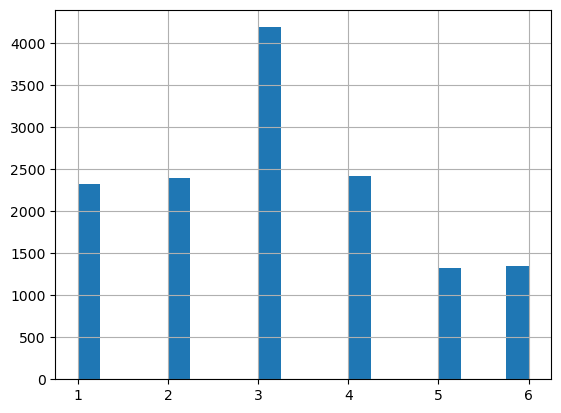

In [96]:
df.parking_space.hist(bins=20)

<Axes: >

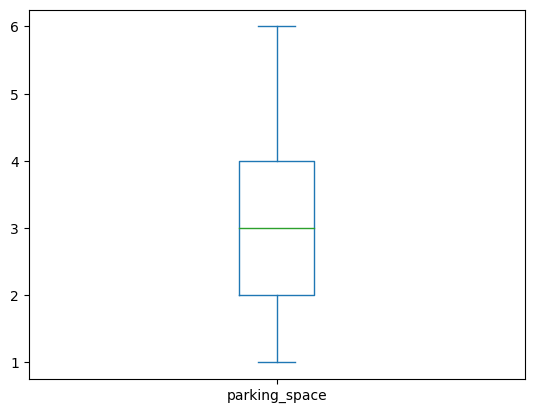

In [97]:
df.parking_space.plot(kind="box")

<Axes: xlabel='bedroom', ylabel='parking_space'>

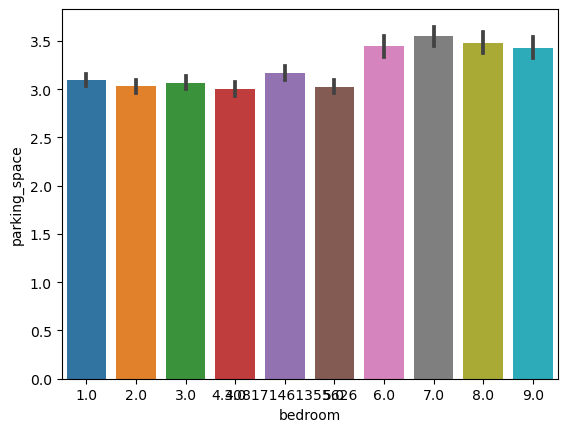

In [98]:
sns.barplot(df, x="bedroom", y="parking_space")

In [121]:
df.location.head()

0    19
1    27
2    12
3     3
4    21
Name: location, dtype: int32

In [119]:
df.location.isnull().sum()

0

In [122]:
df.title.head()

0     7
1     0
2    10
3     3
4     8
Name: title, dtype: int32

In [123]:
df.title.isnull().sum()

0

In [100]:
df.price

0        1149999.565
1        1672416.689
2        3364799.814
3        2410306.756
4        2600700.898
            ...     
13995    2367927.861
13996    2228516.471
13997    2406812.693
13998    3348918.718
13999    2858516.890
Name: price, Length: 14000, dtype: float64

In [103]:
df.price.isnull().sum()

0

STUDYING THE RELATIONSHIP BETWEEN EACH COLUMN

In [124]:
df.location.corr(df.price)

-0.01439457660388426

In [125]:
df.title.corr(df.price)

0.13378476111955118

In [126]:
df.location.corr(df.bedroom)

0.008007864634580931

In [104]:
df.bedroom.corr(df.price)

0.4969128320418359

In [127]:
df.title.corr(df.bedroom)

0.01492417063706471

In [128]:
df.title.corr(df.bathroom)

0.015335844599904273

In [105]:
df.bathroom.corr(df.price)

0.2048018391818756

In [106]:
df.parking_space.corr(df.price)

0.10157766152951767

<Axes: xlabel='bedroom', ylabel='price'>

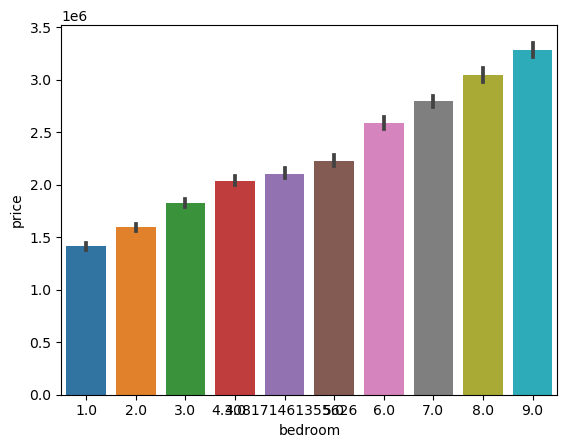

In [129]:
sns.barplot(df, x="bedroom", y="price")

<Axes: xlabel='location', ylabel='price'>

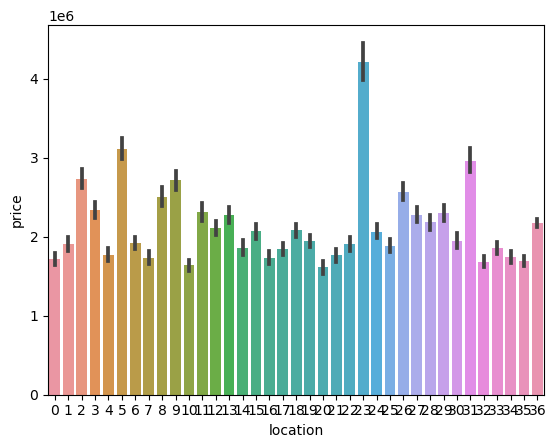

In [130]:
sns.barplot(df, x="location", y="price")

<Axes: xlabel='title', ylabel='location'>

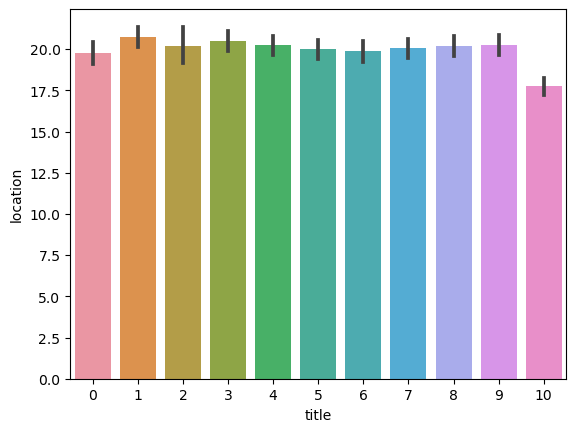

In [131]:
sns.barplot(df, x="title",y="location")

<Axes: xlabel='title', ylabel='price'>

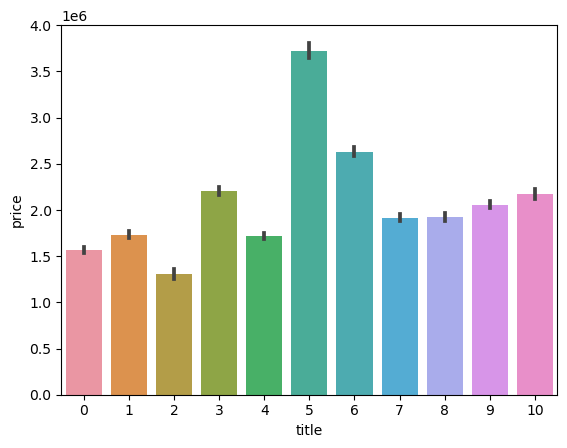

In [132]:
sns.barplot(df, x="title",y="price")

<Axes: xlabel='bathroom', ylabel='price'>

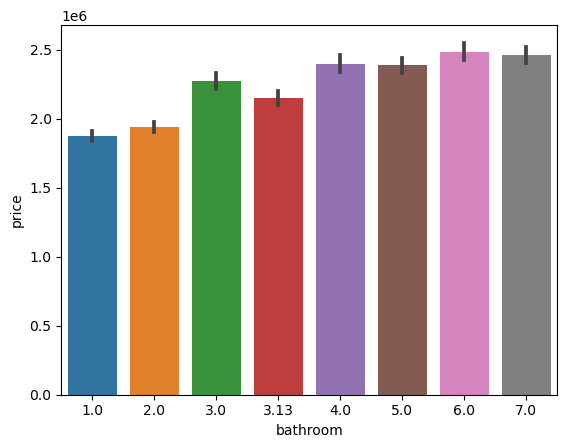

In [108]:
sns.barplot(df, x="bathroom", y="price")

<Axes: >

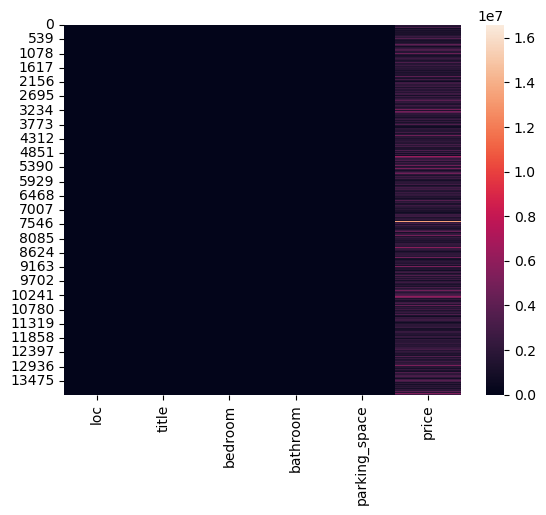

In [109]:
sns.heatmap(df)

C:\Users\PC\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


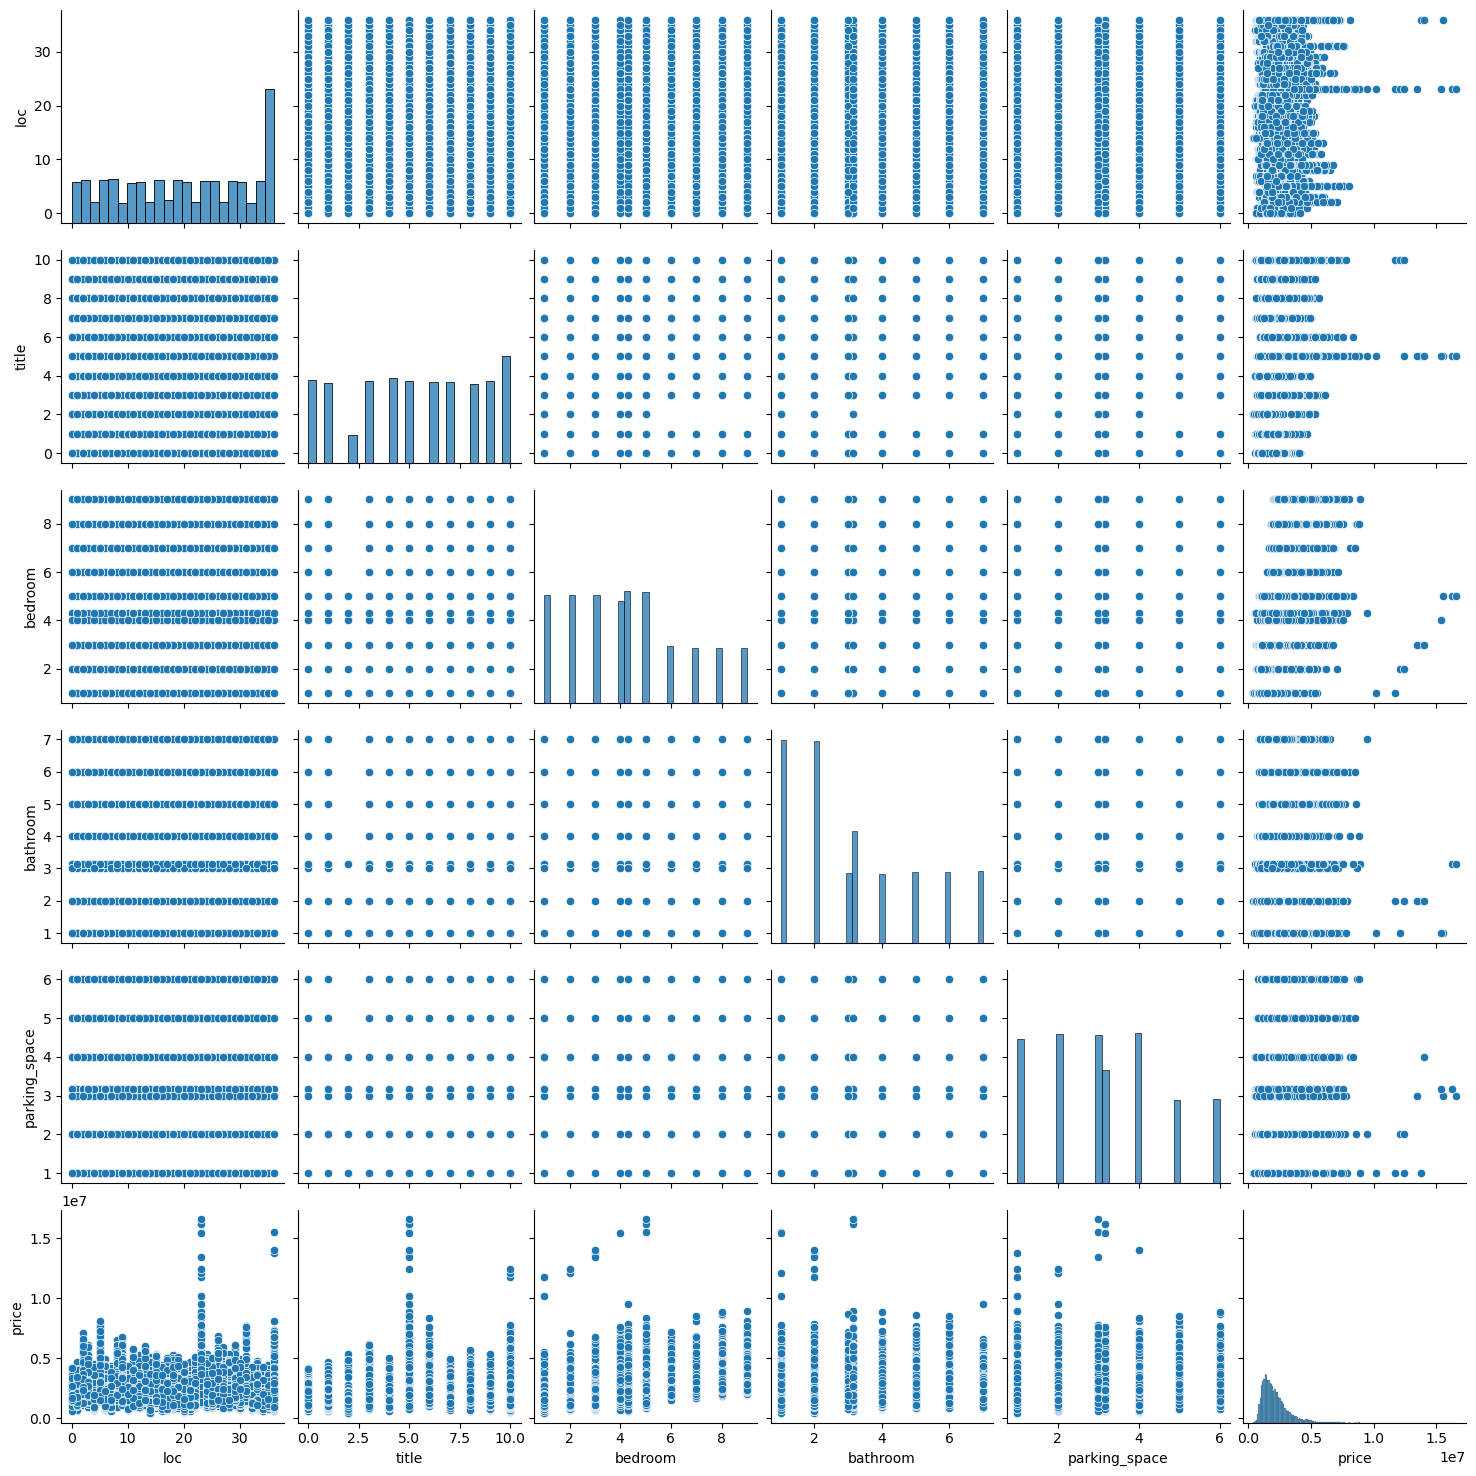

In [110]:
sns.pairplot(df)

In [133]:
df.isnull().sum()

location         0
title            0
bedroom          0
bathroom         0
parking_space    0
price            0
dtype: int64

In [141]:
X = df.drop(columns=["price"])
Y = df['price']

In [324]:
from sklearn.model_selection import train_test_split

In [325]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

ms.fit_transform(X)

array([[0.52777778, 0.7       , 0.125     , 0.16666667, 0.        ],
       [0.75      , 0.        , 0.41352143, 0.16666667, 0.6       ],
       [0.33333333, 1.        , 0.75      , 0.66666667, 0.6       ],
       ...,
       [0.83333333, 0.1       , 0.875     , 0.83333333, 0.8       ],
       [0.25      , 0.4       , 0.41352143, 0.83333333, 0.        ],
       [0.66666667, 1.        , 1.        , 1.        , 0.8       ]])

CREATING A MACHINE LEARING MODEL USING GradientBoostingRegressor

In [326]:
dfx_train,dfx_test,dfy_train,dfy_test = train_test_split(X, Y, train_size=.80, random_state=2)

In [327]:
from sklearn.ensemble import GradientBoostingRegressor

In [146]:
gbc=GradientBoostingRegressor(n_estimators=500, learning_rate=0.1)

In [147]:
gbc.fit(dfx_train, dfy_train)

GradientBoostingRegressor(n_estimators=500)

In [148]:
dfy_pred=gbc.predict(dfx_test)

In [149]:
from sklearn.metrics import mean_squared_error

In [151]:
Nmse=mean_squared_error(dfy_test, dfy_pred)
Nmse

266899410186.66156

In [314]:
from sklearn.linear_model import LinearRegression

In [315]:
lr=LinearRegression()

In [316]:
lr.fit(dfx_train, dfy_train)

LinearRegression()

In [317]:
My_pred=lr.predict(dfx_test)

In [328]:
nmse=mean_squared_error(dfy_test, dfy_pred)
nmse

266899410186.66156

USE OF MODE OF EACH COLUMN TO FILL THE MISSING VALUE OF EACH COLUMN

In [164]:
daf=pd.read_csv("Housing_dataset_train.csv")

In [330]:
daf.head()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [167]:
dfA=daf.rename(columns={"loc":"location"})

In [168]:
dfA.head()

,ID,location,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [169]:
from sklearn.preprocessing import LabelEncoder

In [170]:
le = LabelEncoder()


dfA["location"] =le.fit_transform(dfA["location"])
dfA["title"] = le.fit_transform(dfA["title"])

In [171]:
dfA.head()

,ID,location,title,bedroom,bathroom,parking_space,price
0,3583,19,7,2.0,2.0,1.0,1149999.565
1,2748,27,0,NaN,2.0,4.0,1672416.689
2,9261,12,10,7.0,5.0,NaN,3364799.814
3,2224,3,3,5.0,2.0,4.0,2410306.756
4,10300,21,8,NaN,5.0,6.0,2600700.898


In [175]:
dfA.bedroom.fillna(dfA.bedroom.mode()[0], inplace=True)

In [176]:
dfA.bedroom.isnull().sum()

0

<Axes: >

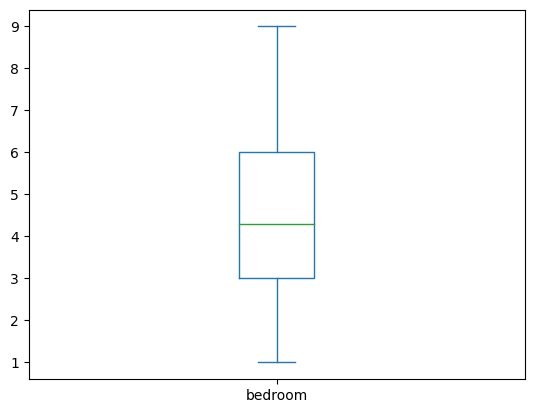

In [222]:
dfA.bedroom.plot(kind="box")

In [177]:
dfA.bathroom.fillna(dfA.bathroom.mode()[0], inplace=True)

In [223]:
dfA.bathroom.isnull().sum()

0

<Axes: >

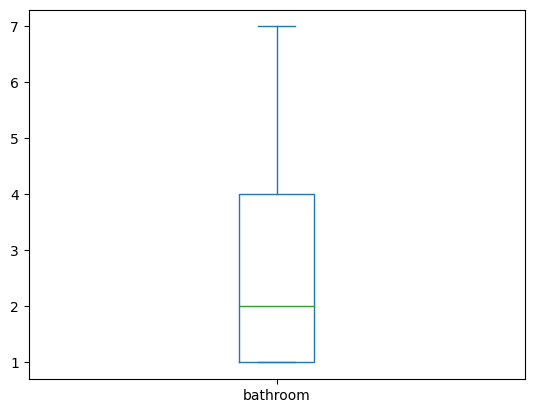

In [224]:
dfA.bathroom.plot(kind="box")

In [179]:
dfA.parking_space.fillna(dfA.parking_space.mode()[0], inplace=True)

In [194]:
dfA.parking_space.head()

0    1.0
1    4.0
2    4.0
3    4.0
4    6.0
Name: parking_space, dtype: float64

In [180]:
dfA.parking_space.isnull().sum()

0

In [181]:
dfA.title.isnull().sum()

0

In [182]:
dfA.location.isnull().sum()

0

In [183]:
dfA.isnull().sum()

ID               0
location         0
title            0
bedroom          0
bathroom         0
parking_space    0
price            0
dtype: int64

C:\Users\PC\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


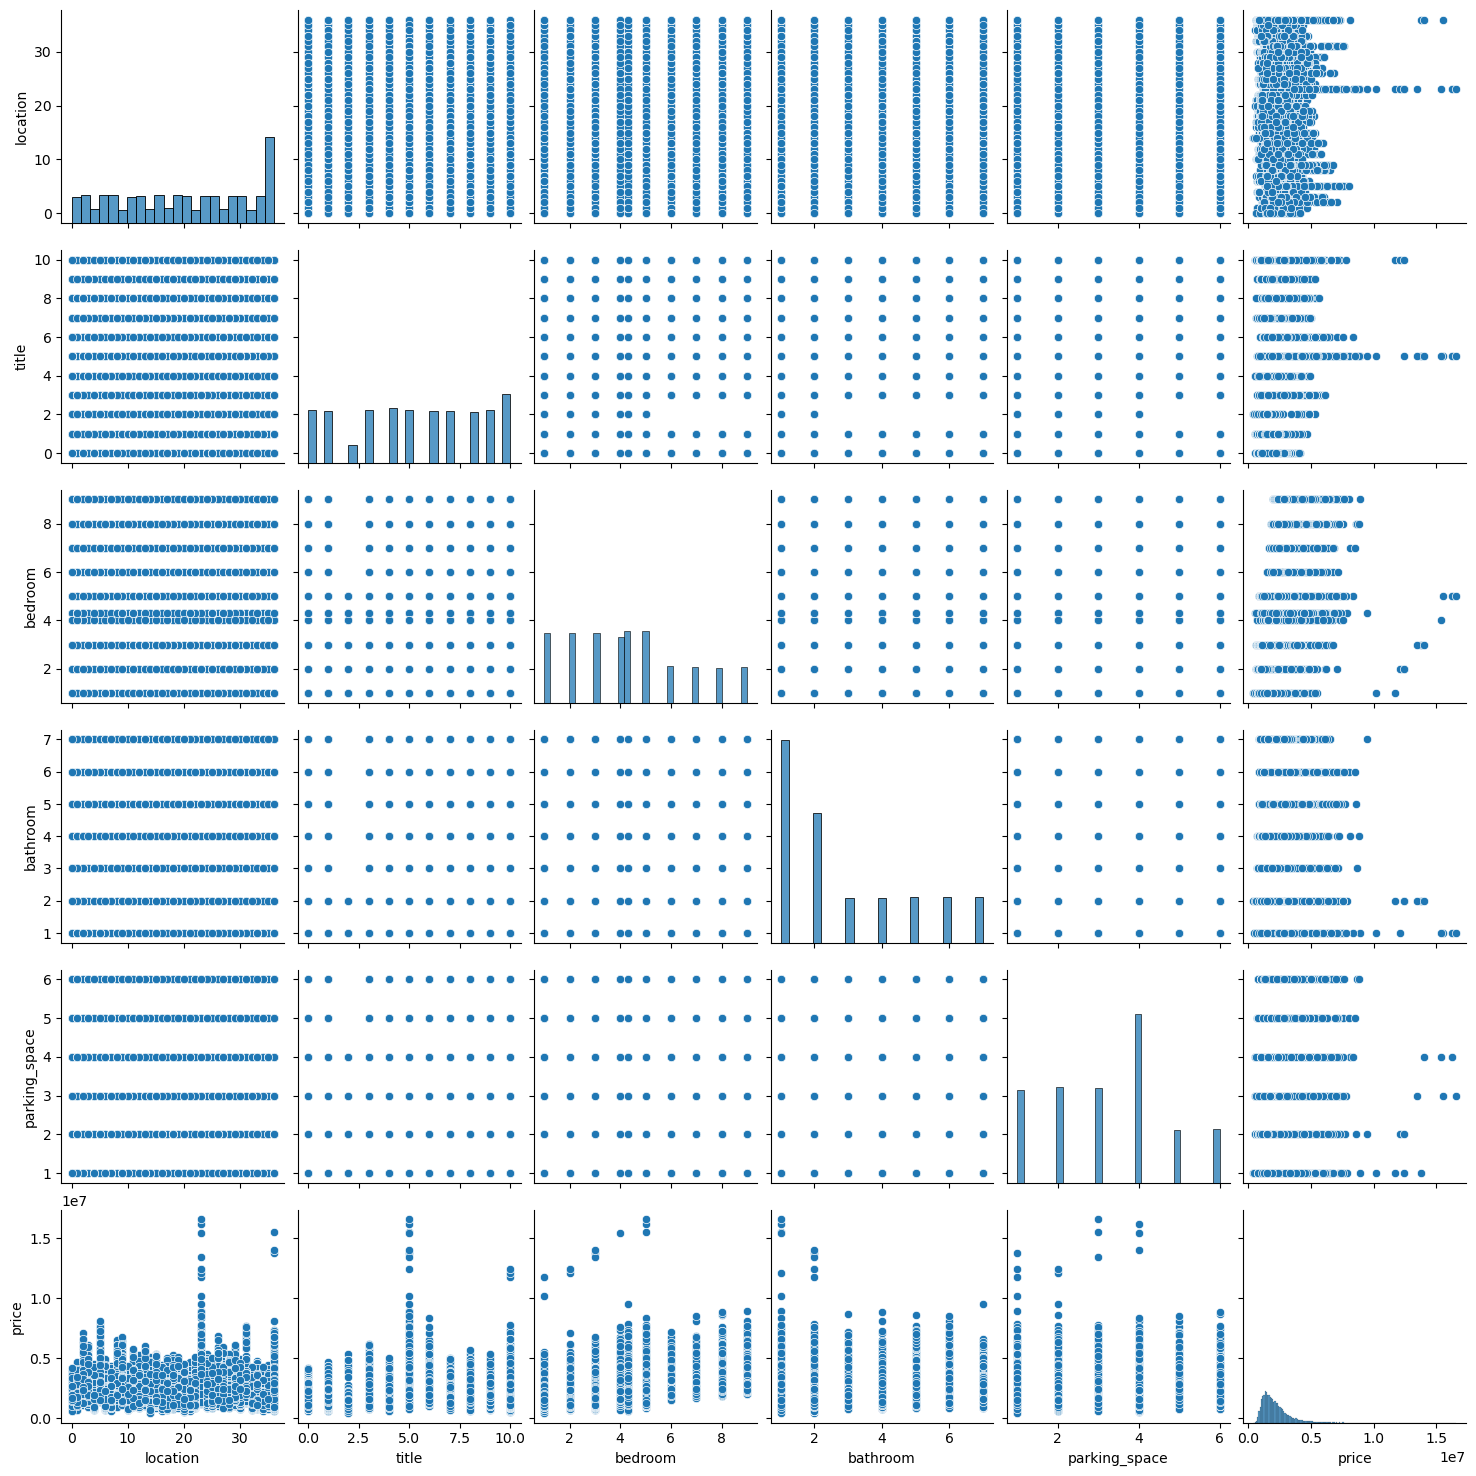

In [225]:
sns.pairplot(dfA)

In [184]:
dfA.columns

Index(['ID', 'location', 'title', 'bedroom', 'bathroom', 'parking_space',
       'price'],
      dtype='object')

In [185]:
dfA.drop("ID", axis=1, inplace=True)

In [196]:
dfA.columns

Index(['location', 'title', 'bedroom', 'bathroom', 'parking_space', 'price'], dtype='object')

In [197]:
Xx = dfA.drop(columns=["price"])
Yy = dfA["price"]

In [198]:
ms = MinMaxScaler()

ms.fit_transform(Xx)

array([[0.52777778, 0.7       , 0.125     , 0.16666667, 0.        ],
       [0.75      , 0.        , 0.41352143, 0.16666667, 0.6       ],
       [0.33333333, 1.        , 0.75      , 0.66666667, 0.6       ],
       ...,
       [0.83333333, 0.1       , 0.875     , 0.83333333, 0.8       ],
       [0.25      , 0.4       , 0.41352143, 0.83333333, 0.        ],
       [0.66666667, 1.        , 1.        , 1.        , 0.8       ]])

USE OF RandomForestRegressor to create a Model

In [199]:
dfX_train,dfX_test,dfY_train,dfY_test = train_test_split(Xx, Yy, train_size=.80, random_state=2)

In [204]:
from sklearn.ensemble import RandomForestRegressor

In [205]:
model = RandomForestRegressor()

In [206]:
model.fit(dfX_train,dfY_train)

RandomForestRegressor()

In [207]:
dfY_pred=model.predict(dfX_test)

In [208]:
Nmse=mean_squared_error(dfY_test, dfY_pred)
Nmse

401316041535.9055

USE OF MEDIAN TO FILL THE MISSING VALUE OF EACH COLUMNS, DATA VISUALIZATION, AND STUDYING THE RELATIONSHIP

In [264]:
new_df=pd.read_csv("Housing_dataset_train.csv")

In [265]:
new_df.head()

,ID,loc,title,bedroom,bathroom,parking_space,price
0,3583,Katsina,Semi-detached duplex,2.0,2.0,1.0,1149999.565
1,2748,Ondo,Apartment,NaN,2.0,4.0,1672416.689
2,9261,Ekiti,NaN,7.0,5.0,NaN,3364799.814
3,2224,Anambra,Detached duplex,5.0,2.0,4.0,2410306.756
4,10300,Kogi,Terrace duplex,NaN,5.0,6.0,2600700.898


In [266]:
New_df=new_df.rename(columns={"loc":"location"})

In [267]:
le = LabelEncoder()

`
New_df["location"] =le.fit_transform(New_df["location"])
New_df["title"] = le.fit_transform(New_df["title"])

In [270]:
New_df.head()

,ID,location,title,bedroom,bathroom,parking_space,price
0,3583,19,7,2.0,2.0,1.0,1149999.565
1,2748,27,0,4.0,2.0,4.0,1672416.689
2,9261,12,10,7.0,5.0,NaN,3364799.814
3,2224,3,3,5.0,2.0,4.0,2410306.756
4,10300,21,8,4.0,5.0,6.0,2600700.898


In [271]:
New_df.bedroom.fillna(New_df.bedroom.median(), inplace=True)

In [269]:
New_df.bedroom.isnull().sum()

0

<Axes: >

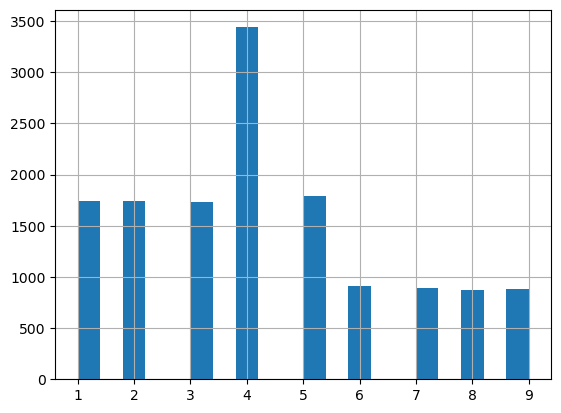

In [272]:
New_df.bedroom.hist(bins=20)

In [273]:
New_df.bathroom.fillna(New_df.bathroom.median(), inplace=True)

In [274]:
New_df.bathroom.isnull().sum()

0

<Axes: >

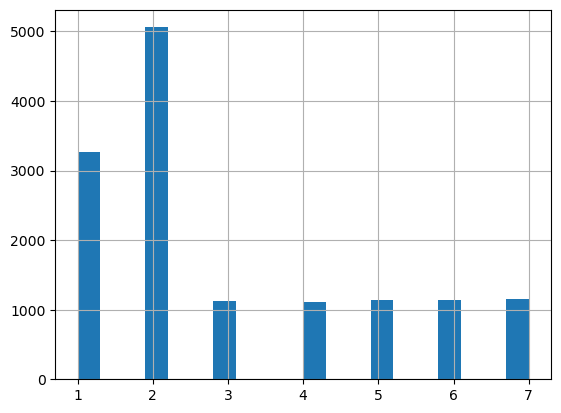

In [275]:
New_df.bathroom.hist(bins=20)

In [277]:
New_df.parking_space.fillna(New_df.parking_space.median(), inplace=True)

<Axes: >

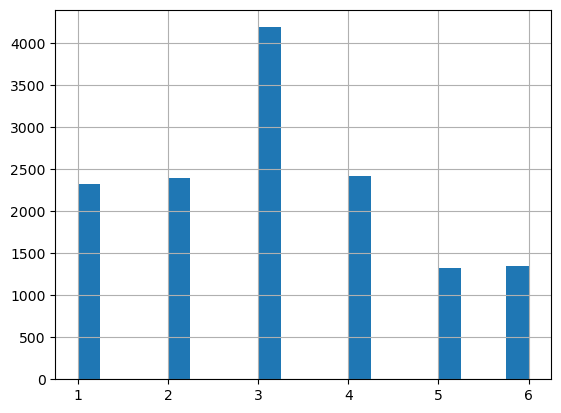

In [278]:
New_df.parking_space.hist(bins=20)

In [279]:
New_df.isnull().sum()

ID               0
location         0
title            0
bedroom          0
bathroom         0
parking_space    0
price            0
dtype: int64

In [280]:
New_df.columns

Index(['ID', 'location', 'title', 'bedroom', 'bathroom', 'parking_space',
       'price'],
      dtype='object')

In [281]:
New_df.drop("ID", axis=1, inplace=True)

In [282]:
New_df.columns

Index(['location', 'title', 'bedroom', 'bathroom', 'parking_space', 'price'], dtype='object')

In [283]:
xx = dfA.drop(columns=["price"])
yy = dfA["price"]

USE OF KNEIGHBORSREGRESSOR TO CREATE A A MACHINE LEARNING MODEL

In [284]:
df_X_train,df_X_test,df_Y_train,df_Y_test = train_test_split(xx, yy, train_size=.80, random_state=2)

In [285]:
from sklearn.neighbors import KNeighborsRegressor

In [286]:
knn = KNeighborsRegressor(n_neighbors=3)

In [287]:
knn.fit(df_X_train,df_Y_train)

KNeighborsRegressor(n_neighbors=3)

In [292]:
df_Y_pred=knn.predict(df_X_test)

In [293]:
mse=mean_squared_error(df_Y_test, df_Y_pred)
mse

594065203269.1407

USE OF DECISIONTREEREGRESSOR TO CREATE A MACHINE LEARNING MODEL USING MEDIAN TO FILL THE MISISNG VALUE

In [294]:
from sklearn.tree import DecisionTreeRegressor

In [295]:
model = DecisionTreeRegressor()

In [297]:
model.fit(df_X_train,df_Y_train)

DecisionTreeRegressor()

In [298]:
Ny_pred = model.predict(df_X_test)

In [299]:
mse = mean_squared_error(df_Y_test,Ny_pred)
mse

676954184216.9008